In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy
import h5py

#path = 'D:/Dataset/The dataset/2020-02-18 Human Trial [20]/Data/'
path = 'D:/Dataset/The dataset/2020-10-12 Human Trial [21]/Data/'
#f_lst = os.listdir(path)
f_lst = ['Data_20201013_102512.mat', 'Data_20201013_100258.mat', 'Data_20201013_095350.mat', 'Data_20201013_103318.mat', 'Data_20201013_103735.mat', 'Data_20201013_104352.mat', 'Data_20201013_104738.mat', 'Data_20201013_110117.mat', 'Data_20201013_110311.mat', 'Data_20201013_170923.mat', 'Data_20201013_171706.mat']

dataset = []
for f in f_lst:
    file_path = os.path.join(path, f)
    print(f"\n--- {f} ---")

    with h5py.File(file_path, 'r') as mat:
        #print("Keys:", list(mat.keys()))

        def load_hdf5(obj):
            if isinstance(obj, h5py.Dataset):
                return obj[()]
            elif isinstance(obj, h5py.Group):
                out = {}
                for k, v in obj.items():
                    out[k] = load_hdf5(v)
                return out

        data = {k: load_hdf5(v) for k, v in mat.items()}
        raw_signal = data['Data_ADC0'].T[1000:]
        dataset.append(raw_signal)


--- Data_20201013_102512.mat ---

--- Data_20201013_100258.mat ---

--- Data_20201013_095350.mat ---

--- Data_20201013_103318.mat ---

--- Data_20201013_103735.mat ---

--- Data_20201013_104352.mat ---

--- Data_20201013_104738.mat ---

--- Data_20201013_110117.mat ---

--- Data_20201013_110311.mat ---

--- Data_20201013_170923.mat ---

--- Data_20201013_171706.mat ---


In [3]:
dataset[1].shape

(834185, 16)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10000 #round(10e6 / 2048)
fft_len = 2**14
num_channels = 16

# Store FFT magnitudes & dominant frequencies
emg_all_fft = []
emg_dom_freqs = []

for s_idx in range(len(dataset[:-1])):
    EMG_all = dataset[s_idx]     # shape (X, 16)

    for ch in range(num_channels):
        # Extract channel signal
        emg_signal = EMG_all[:, ch]

        # DC removal
        emg_signal = emg_signal - np.mean(emg_signal)

        # FFT
        emg_fft = np.fft.fft(emg_signal, n=fft_len)
        freqs = np.fft.fftfreq(len(emg_fft), d=1/fs)

        # positive frequencies only
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        emg_fft_mag = np.abs(emg_fft[pos_mask])

        # Store
        emg_all_fft.append(emg_fft_mag)
        emg_dom_freqs.append(freqs[np.argmax(emg_fft_mag)])

# Convert to arrays
emg_all_fft = np.array(emg_all_fft)
emg_dom_freqs = np.array(emg_dom_freqs)

# Compute statistics
emg_mean_fft = np.mean(emg_all_fft, axis=0)
emg_std_fft  = np.std(emg_all_fft, axis=0)
emg_var_fft  = np.var(emg_all_fft, axis=0)
emg_dom_freq_mean = np.mean(emg_dom_freqs)

print(f"ENG dominant freq mean: {emg_dom_freq_mean:.2f} Hz")
print(f"ENG dominant freq variance: {np.var(emg_dom_freqs):.2f} Hz^2")

EMG dominant freq mean: 100.36 Hz
EMG dominant freq variance: 308728.80 Hz^2


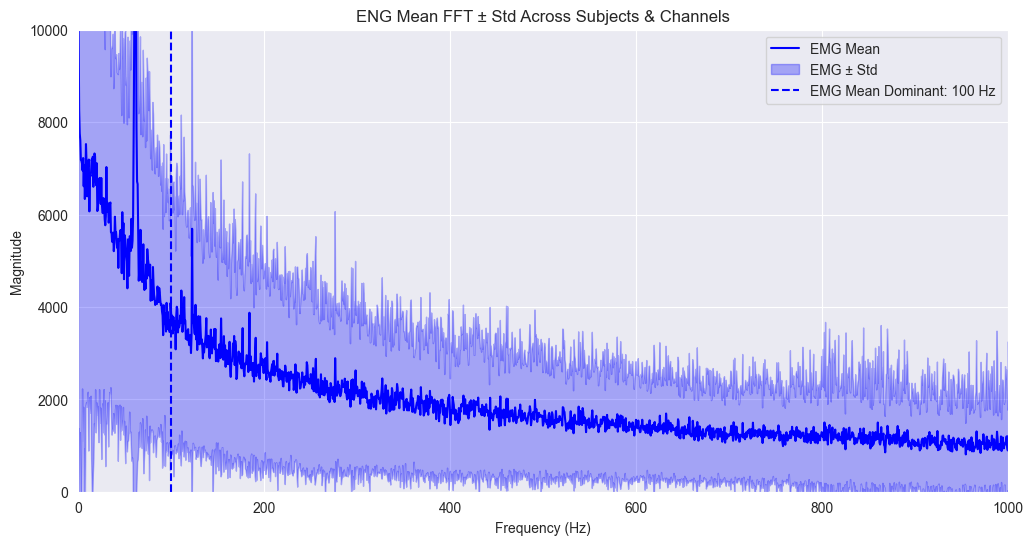

In [18]:
plt.figure(figsize=(12, 6))

# Plot mean curve
plt.plot(freqs, emg_mean_fft, label=f'EMG Mean', color='blue')

# Plot std shading
plt.fill_between(freqs,
                 emg_mean_fft - emg_std_fft,
                 emg_mean_fft + emg_std_fft,
                 color='blue', alpha=0.3,
                 label='EMG ± Std')

# Dominant frequency (mean)
plt.axvline(emg_dom_freq_mean, color='blue', linestyle='--',
            label=f'EMG Mean Dominant: {int(emg_dom_freq_mean)} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('ENG Mean FFT ± Std Across Subjects & Channels')
plt.legend()
plt.ylim(0, 10000)
plt.xlim(0, 1000)
plt.show()
